# Meter Maintenance Notebook

Use the main notebook for the normal pipeline run.

- inspect one meter or a few meters closely
- compare raw data to the current broken meter source entry
- review the raw readings captured inside remove/broken windows
- decide whether a meter is still broken, repaired, misclassified, or needs a date change
- keep a small update log
- create a reviewed copy of the broken meter source file
- optionally write confirmed changes back to the source file

### Files explanation

- `running_list_broken_meters.xlsx` = **source of truth** broken meter file
- `removed_special_meter_data.csv` = **raw readings captured** inside remove/broken windows
- `special_meter_candidates.xlsx` = current review candidate workbook
- `special_meters_corrections_master_sheet.xlsx` = generated master corrections workbook


In [1]:
# TODO: make sure removed special is in order of meter, datetime
# TODO: check if removed special is duplicating with broken intervals (double check)
# rename interval to clean 

In [2]:
import os
import importlib
import numpy as np
import pandas as pd
import data_clean_TEST as dc
importlib.reload(dc)

<module 'data_clean_TEST' from '/Users/cassiehuber/Documents/GitHub/harvest_kwh_prep/notebooks/data_clean_TEST.py'>

In [3]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

### 1. Parameters

In [4]:
############ CHANGE PARAMETERS AS NEEDED #############

# review every meter from the broken source file that has a status in BROKEN_STATUS_VALUES
review_all_broken_status_meters = True

# leave empty if using automatic broken-meter selection
meters_to_review = []

# optional zoom window for plots
zoom_start = None   # e.g. "2025-08-01 00:00:00"
zoom_end = None     # e.g. "2025-10-01 00:00:00"

# whether to save changes back to the source broken meter file
write_changes_to_source_file = False

######################################################

In [5]:
# Paths
input_dir = "../data/extracts/"
output_dir = "../data/outputs/"
plot_dir = "../data/outputs/plots/"
maintenance_dir = "../data/outputs/maintenance/"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(maintenance_dir, exist_ok=True)

# TODO: change to server paths if running on server, make be all of its meter data or a subset
# Main raw meter data for this run
var_file = input_dir + "harvest_kwh_15min_" + "250723-251017.csv"

# TODO: FIX

# Main pipeline source/review files
meter_issues_candidates_file = input_dir + "special_meter_candidates.xlsx"
meter_issues_file = input_dir + "special_meters.xlsx"
broken_meters_file = input_dir + "running_list_broken_meters.xlsx"  #broken meter workbook

# Main pipeline generated files
meter_corrections_file = output_dir + "special_meters_corrections_master_sheet.xlsx"
removed_special_meter_data_file = output_dir + "removed_special_meter_data.csv"

# Maintenance files
broken_meter_update_log_file = maintenance_dir + "broken_meter_update_log.csv"
broken_meter_reviewed_copy_file = maintenance_dir + "running_list_broken_meters_reviewed_copy.xlsx"
maintenance_plot_file = plot_dir + "maintenance_review_selected_meters.pdf"


section ideas:

- load one meter or selected meters
- plot raw data around chosen dates
- compare against current broken list entry
- decide update: broken / repaired / not actually broken
- save changes back to the source file / or database


### Load raw data and review/source files

In [6]:
def _empty_removed_df():
    return pd.DataFrame(columns=[
        "datetime",
        "meter_name",
        "meter_reading",
        "solution",
        "correction_start",
        "correction_end",
        "issue_type/status",
        "description",
    ])

In [7]:
# Load raw interval data
#TODO: change to load from server
raw_df = pd.read_csv(var_file)
raw_df["datetime"] = pd.to_datetime(raw_df["datetime"], errors="coerce")
raw_df = raw_df.dropna(subset=["datetime"]).copy()

required_raw_cols = {"datetime", "meter_name", "meter_reading"}
missing_raw_cols = required_raw_cols.difference(set(raw_df.columns))
if missing_raw_cols:
    raise ValueError(f"Raw interval file is missing required columns: {sorted(missing_raw_cols)}")

# Pivot to wide meter dataframe and fill missing timestamps
pivoted_df = raw_df.pivot(index="datetime", columns="meter_name", values="meter_reading").reset_index()
full_df = dc.fill_missing_timestamps(pivoted_df, "15min")
data = full_df.set_index("datetime").sort_index()

# Load broken meter source file
broken_source_df = dc.load_broken_meter_workbook(broken_meters_file)

# Build review meter list automatically from broken source statuses
data_cols_norm = {str(col).strip().lower() for col in data.columns}

all_broken_status_meters = sorted(
    broken_source_df["meter_name"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
    .tolist()
)

meters_not_in_data = sorted([m for m in all_broken_status_meters if m not in data_cols_norm])

if review_all_broken_status_meters:
    meters_to_review = sorted([m for m in all_broken_status_meters if m in data_cols_norm])

print("all broken-status meters from source file:", len(all_broken_status_meters))
print("meters_to_review found in raw data:", len(meters_to_review))
print("broken-status meters not found in raw data:", len(meters_not_in_data))

if meters_not_in_data:
    print("Not in raw data:")
    print(meters_not_in_data)


# Load candidate workbook
candidate_df = dc._load_existing_candidates(meter_issues_candidates_file)


# Load manual special meters source
manual_special_df = dc._load_base_master_corrections(meter_issues_file)

# Load generated master corrections workbook if present
if os.path.exists(meter_corrections_file):
    master_corrections_df = pd.read_excel(meter_corrections_file)
else:
    master_corrections_df = pd.DataFrame(columns=[
        "meter_name", "solution", "start_datetime", "end_datetime", "issue_type/status", "description"
    ])

# Load removed raw data captured inside remove/broken windows
if os.path.exists(removed_special_meter_data_file):
    removed_df = pd.read_csv(removed_special_meter_data_file)
    for col in ["datetime", "correction_start", "correction_end"]:
        if col in removed_df.columns:
            removed_df[col] = pd.to_datetime(removed_df[col], errors="coerce")
else:
    removed_df = _empty_removed_df()

print("raw_df shape:", raw_df.shape)
print("data shape:", data.shape)
print("broken_source_df rows:", len(broken_source_df))
print("removed_df rows:", len(removed_df))


all broken-status meters from source file: 30
meters_to_review found in raw data: 11
broken-status meters not found in raw data: 19
Not in raw data:
['campus_center_ac_main', 'ching_complex_main', 'hale_noelani_all_towers_main', 'hale_noelani_tower_a_b', 'hale_noelani_tower_b', 'hale_noelani_tower_c', 'hale_noelani_tower_c_d', 'hale_noelani_tower_e', 'hig_substation_1_main', 'hig_substation_2_main', 'hig_substation_3_main', 'it_center_main', 'korean_studies_main', 'law_clinic_main', 'law_school_ac_main', 'pope_lab_main', 'quad_chiller_plant_main', 'saunders_hall_main_a', 'softball_tennis_main']
raw_df shape: (551952, 3)
data shape: (8264, 87)
broken_source_df rows: 31
removed_df rows: 42366


/Users/cassiehuber/Documents/GitHub/harvest_kwh_prep/notebooks/data_clean_TEST.py:763: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["updated_data"] = pd.to_datetime(df["updated_data"], errors="coerce", dayfirst=dayfirst)


In [8]:
# previews
# if meters_to_review:
#     selected_broken = 

### Meter review plot(s)

In [ ]:
def plot_meter_maintenance_review(
    meter_name,
    data,
    broken_source_df,
    candidate_df,
    removed_df,
    zoom_start=None,
    zoom_end=None,
):
    meter_name_norm = str(meter_name).strip().lower()

    if meter_name_norm not in [str(col).strip().lower() for col in data.columns]:
        print(f"{meter_name} not found in data columns.")
        return None

    # map normalized meter name back to actual data column name
    data_col = None
    for col in data.columns:
        if str(col).strip().lower() == meter_name_norm:
            data_col = col
            break

    meter_series = data[data_col].copy()

    meter_broken = broken_source_df[broken_source_df["meter_name"] == meter_name_norm].copy()
    meter_candidates = candidate_df[candidate_df["meter_name"] == meter_name_norm].copy()
    meter_removed = removed_df[removed_df["meter_name"].astype(str).str.strip().str.lower() == meter_name_norm].copy()

    plot_start = pd.to_datetime(meter_series.index.min())
    plot_end = pd.to_datetime(meter_series.index.max())

    if zoom_start is not None:
        zoom_start_dt = pd.to_datetime(zoom_start)
        plot_start = max(plot_start, zoom_start_dt)
    if zoom_end is not None:
        zoom_end_dt = pd.to_datetime(zoom_end)
        plot_end = min(plot_end, zoom_end_dt)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(meter_series.index, meter_series.values, linewidth=1.2)
    ax.set_xlim(plot_start, plot_end)
    ax.set_title(meter_name_norm)
    ax.set_xlabel("Datetime")
    ax.set_ylabel("kWh")
    ax.grid(True, alpha=0.3)

    # broken source intervals = red spans
    for _, row in meter_broken.iterrows():
        start = plot_start if pd.isna(row["start_date"]) else max(pd.to_datetime(row["start_date"]), plot_start)
        end = plot_end if pd.isna(row["end_date"]) else min(pd.to_datetime(row["end_date"]), plot_end)
        if start <= end:
            ax.axvspan(start, end, alpha=0.2, color="red")

    # candidate intervals = blue spans
    for _, row in meter_candidates.iterrows():
        start = pd.to_datetime(row["start_datetime"], errors="coerce")
        end = pd.to_datetime(row["end_datetime"], errors="coerce")
        if pd.notna(start) and pd.notna(end):
            start = max(start, plot_start)
            end = min(end, plot_end)
            if start <= end:
                ax.axvspan(start, end, alpha=0.2, color="blue")

    # removed raw readings = orange points
    if not meter_removed.empty and "datetime" in meter_removed.columns and "meter_reading" in meter_removed.columns:
        removed_plot = meter_removed[
            (meter_removed["datetime"] >= plot_start) & (meter_removed["datetime"] <= plot_end)
        ].copy()
        if not removed_plot.empty:
            ax.scatter(
                removed_plot["datetime"],
                removed_plot["meter_reading"],
                s=10,
                alpha=0.8,
                marker="o",
                color="orange",
            )

    issue_types = [
        str(value).strip()
        for value in pd.unique(meter_candidates["issue_type"].dropna())
        if str(value).strip() != ""
    ]

    r2_values = [
        str(value).strip()
        for value in pd.unique(meter_candidates["r2"].dropna())
        if str(value).strip() != ""
    ]

    status_values = [
        str(value).strip()
        for value in pd.unique(meter_broken["status"].dropna())
        if str(value).strip() != ""
    ]

    annotation_lines = []
    if status_values:
        annotation_lines.append("Broken status: " + ", ".join(status_values))
    if issue_types:
        annotation_lines.append("Candidate issue type: " + ", ".join(issue_types))
    if r2_values:
        annotation_lines.append("Candidate r2: " + ", ".join(r2_values))
    if not meter_removed.empty:
        annotation_lines.append(f"Removed raw points: {len(meter_removed)}")

    if annotation_lines:
        ax.text(
            0.05, 0.95,
            "\n".join(annotation_lines),
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

    plt.tight_layout()
    return fig


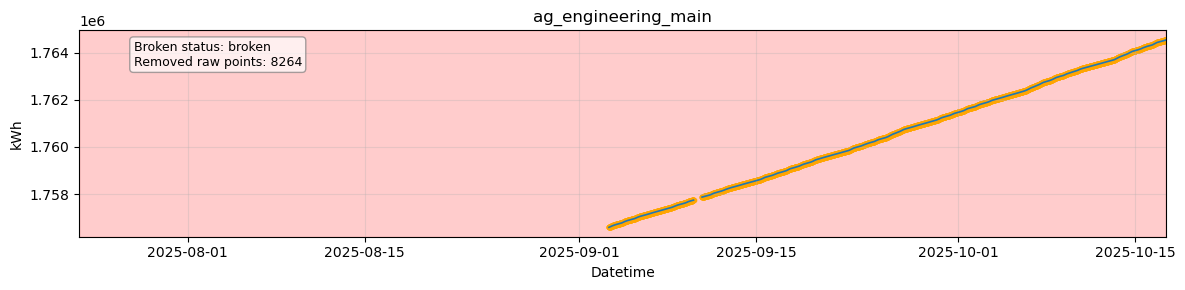

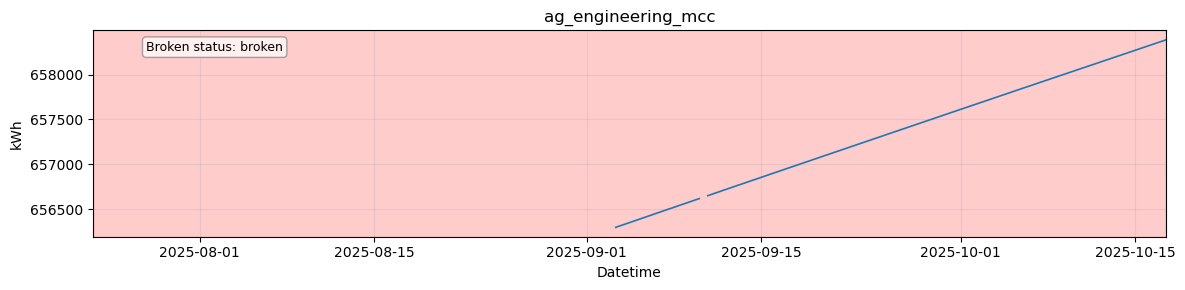

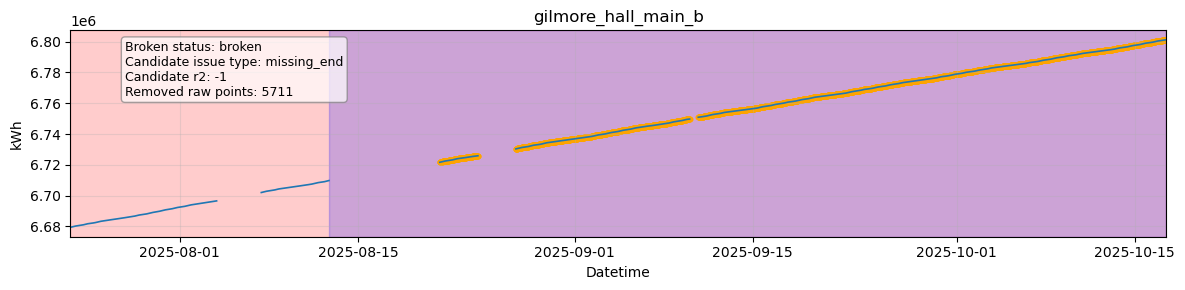

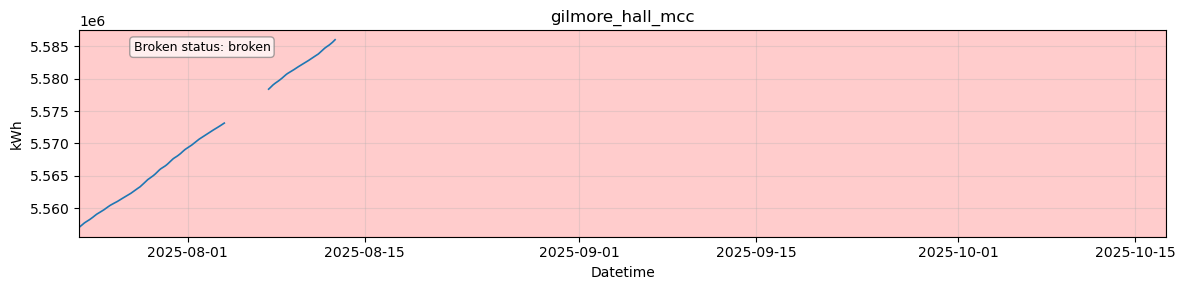

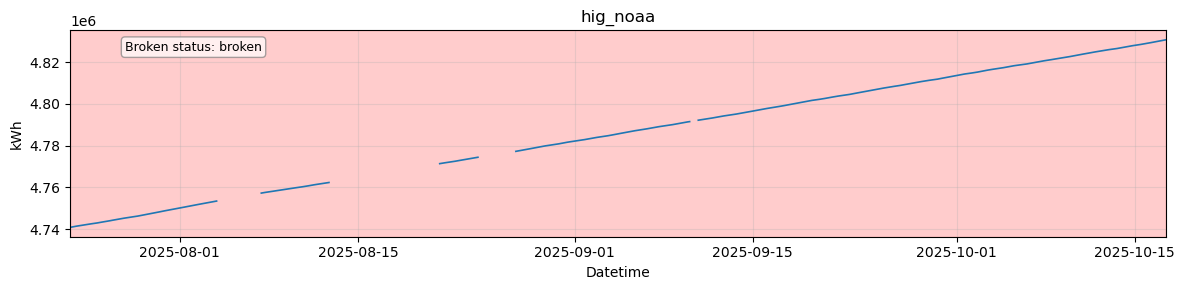

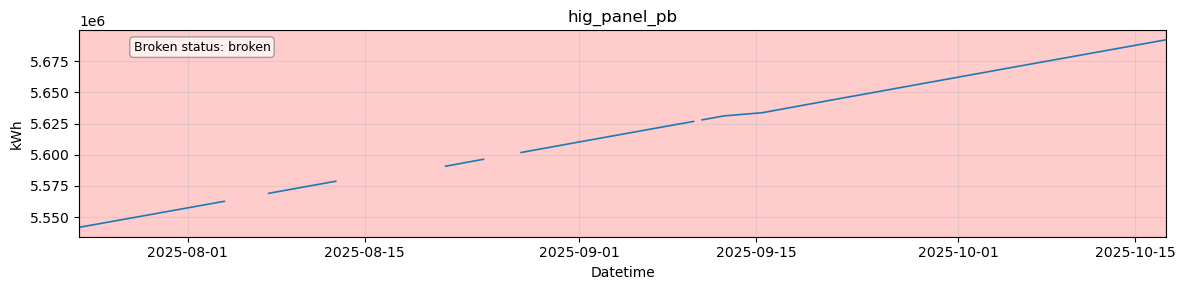

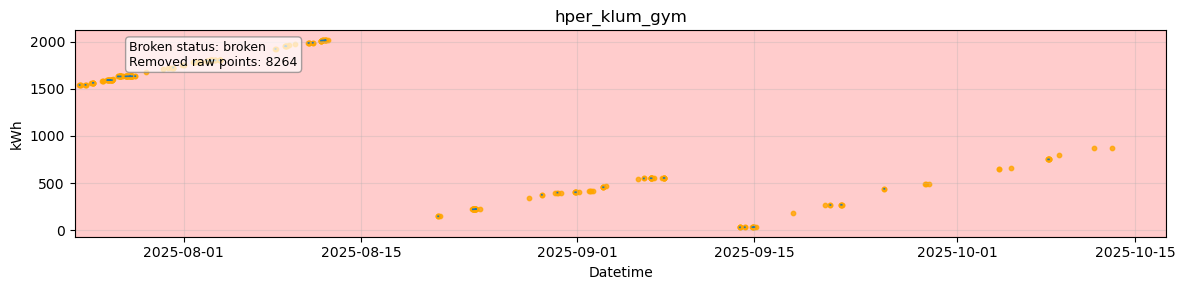

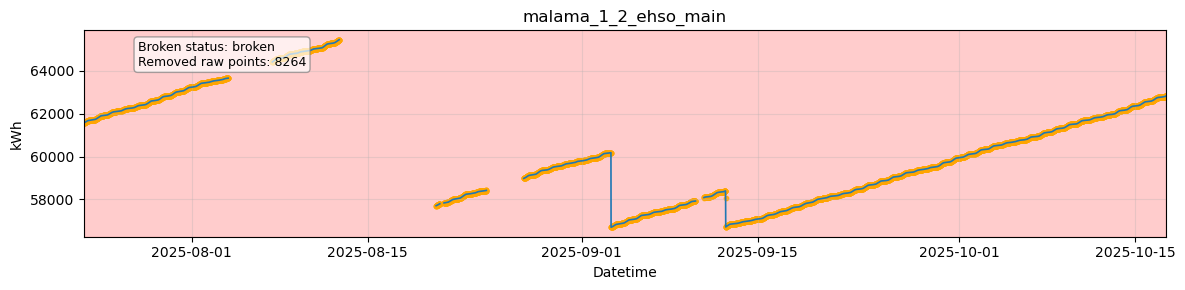

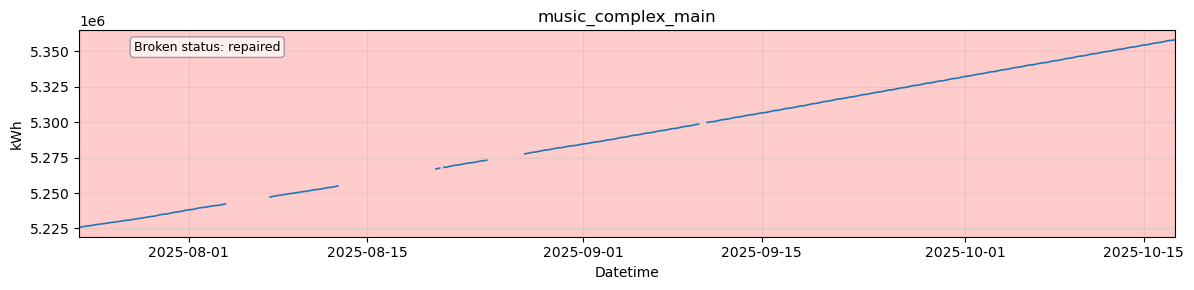

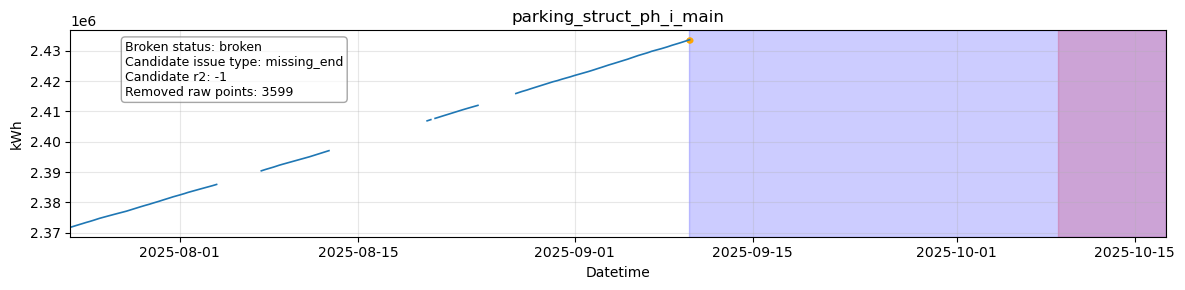

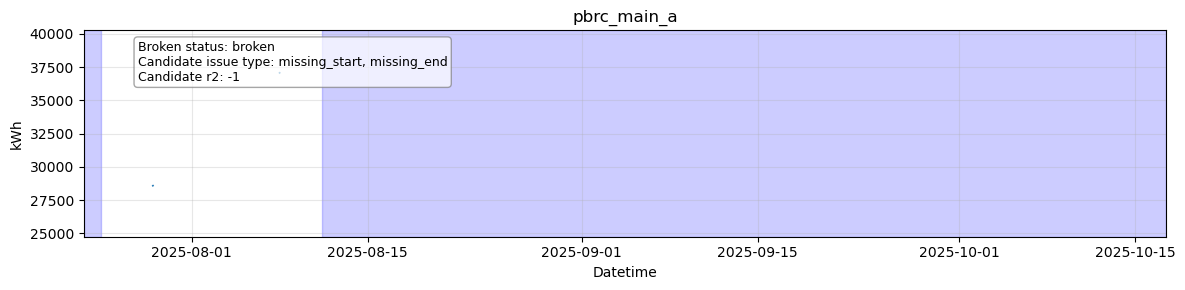

Saved maintenance review plots to ../data/outputs/plots/maintenance_review_selected_meters.pdf


In [10]:
# Plot selected meters
if not meters_to_review:
    print("Add one or more meter names to meters_to_review first.")
else:
    saved_count = 0
    with PdfPages(maintenance_plot_file) as pdf:
        for meter_name in meters_to_review:
            fig = plot_meter_maintenance_review(
                meter_name=meter_name,
                data=data,
                broken_source_df=broken_source_df,
                candidate_df=candidate_df,
                removed_df=removed_df,
                zoom_start=zoom_start,
                zoom_end=zoom_end,
            )
            if fig is not None:
                pdf.savefig(fig, bbox_inches="tight")
                plt.show()
                plt.close(fig)
                saved_count += 1

    if saved_count > 0:
        print(f"Saved maintenance review plots to {maintenance_plot_file}")


## Plot legend:
- blue line  = raw meter readings
- orange dots = raw readings captured in `removed_special_meter_data.csv`
- red spans   = broken intervals from `running_list_broken_meters.xlsx`
- blue spans  = candidate issue intervals from `special_meter_candidates.xlsx`
- purple spans = both red and blue spans